In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split


In [104]:
# df1=pd.read_parquet('D:/AHU/rdm-wach-ai/paraquet_data/raw/raw_one_year.parquet',engine="pyarrow")
# df1.head(2)
df=pd.read_parquet('D:/AHU/rdm-wach-ai/paraquet_data/cleaned/raw_data_e0201.parquet',engine="pyarrow")
df.head(2)

,time,result,table,controller,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
0,2025-11-05 07:00:00+00:00,0.0,1.5,e0201,0.0,0.740000,0.0,9.798571,3.992857,7.208571,234.142857,233.257143,234.657143,3.617649
1,2025-11-05 07:15:00+00:00,0.0,1.5,e0201,0.0,0.736667,0.0,9.820000,4.016667,7.203333,233.733333,232.850000,234.283333,3.615877


In [59]:
df.columns

Index(['time', 'result', 'table', 'controller', 'site', 'power_factor_avg',
       'units', 'current_l1', 'current_l2', 'current_l3', 'volts_l1_n',
       'volts_l2_n', 'volts_l3_n', 'power_total'],
      dtype='object')

In [60]:
df.describe()

,result,table,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
count,9476.0,9476.000000,9476.0,9476.000000,9476.0,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000
mean,0.0,1.496101,0.0,0.675504,0.0,9.248912,3.470464,5.686167,235.222140,234.473515,236.497697,2.936665
std,0.0,0.023961,0.0,0.062977,0.0,0.898504,0.770090,1.529796,1.917521,1.958178,1.986731,0.587143
min,0.0,1.400000,0.0,0.412500,0.0,2.798750,0.120000,0.180000,230.514286,229.557143,231.250000,0.383848
25%,0.0,1.500000,0.0,0.637143,0.0,8.770000,2.991250,4.443571,233.842857,233.075000,235.085714,2.399075
50%,0.0,1.500000,0.0,0.690000,0.0,9.751250,3.930000,5.839911,235.366667,234.500000,236.642857,2.959128
75%,0.0,1.500000,0.0,0.725000,0.0,9.871429,4.012500,6.528143,236.600000,236.000000,237.871429,3.306097
max,0.0,1.600000,0.0,0.830000,0.0,10.107143,4.215000,9.391429,240.350000,239.250000,242.050000,4.181976


In [61]:
print("Total Rows:", len(df))
print("\nColumns:", df.columns.tolist())

Total Rows: 9476

Columns: ['time', 'result', 'table', 'controller', 'site', 'power_factor_avg', 'units', 'current_l1', 'current_l2', 'current_l3', 'volts_l1_n', 'volts_l2_n', 'volts_l3_n', 'power_total']


In [62]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
time                0
result              0
table               0
controller          0
site                0
power_factor_avg    0
units               0
current_l1          0
current_l2          0
current_l3          0
volts_l1_n          0
volts_l2_n          0
volts_l3_n          0
power_total         0
dtype: int64


In [63]:
ranges = {
    'power_total': (0, 15),
    'current_l1': (0, 25),
    'current_l2': (0, 25),
    'current_l3': (0, 25),
    'volts_l1_n': (200, 260),
    'volts_l2_n': (200, 260),
    'volts_l3_n': (200, 260),
    'power_factor_avg': (0, 1.0),
}

print("\nOut of Range Counts:")
for col, (min_val, max_val) in ranges.items():
    if col in df.columns:
        invalid = ((df[col] < min_val) | (df[col] > max_val)).sum()
        print(f"{col}: {invalid}")


Out of Range Counts:
power_total: 0
current_l1: 0
current_l2: 0
current_l3: 0
volts_l1_n: 0
volts_l2_n: 0
volts_l3_n: 0
power_factor_avg: 0


In [64]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,result,table,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total
count,9476.0,9476.000000,9476.0,9476.000000,9476.0,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000,9476.000000
mean,0.0,1.496101,0.0,0.675504,0.0,9.248912,3.470464,5.686167,235.222140,234.473515,236.497697,2.936665
std,0.0,0.023961,0.0,0.062977,0.0,0.898504,0.770090,1.529796,1.917521,1.958178,1.986731,0.587143
min,0.0,1.400000,0.0,0.412500,0.0,2.798750,0.120000,0.180000,230.514286,229.557143,231.250000,0.383848
25%,0.0,1.500000,0.0,0.637143,0.0,8.770000,2.991250,4.443571,233.842857,233.075000,235.085714,2.399075
50%,0.0,1.500000,0.0,0.690000,0.0,9.751250,3.930000,5.839911,235.366667,234.500000,236.642857,2.959128
75%,0.0,1.500000,0.0,0.725000,0.0,9.871429,4.012500,6.528143,236.600000,236.000000,237.871429,3.306097
max,0.0,1.600000,0.0,0.830000,0.0,10.107143,4.215000,9.391429,240.350000,239.250000,242.050000,4.181976


In [65]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

time_diff = df['time'].diff().value_counts()
print("\nTime Gap Distribution:")
print(time_diff.head())


Time Gap Distribution:
time
0 days 00:15:00    9475
Name: count, dtype: int64


In [66]:
print("\nCorrelation with Power Total:")
corr = df.corr(numeric_only=True)
print(corr['power_total'].sort_values(ascending=False))


Correlation with Power Total:
power_total         1.000000
current_l2          0.824140
current_l3          0.794431
current_l1          0.783848
power_factor_avg    0.612793
table              -0.030880
volts_l1_n         -0.205972
volts_l2_n         -0.217396
volts_l3_n         -0.314355
result                   NaN
site                     NaN
units                    NaN
Name: power_total, dtype: float64


In [105]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)
# Add time features
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek
df['month'] = df['time'].dt.month

In [106]:
df

,time,result,table,controller,site,power_factor_avg,units,current_l1,current_l2,current_l3,volts_l1_n,volts_l2_n,volts_l3_n,power_total,hour,dayofweek,month
0,2025-11-05 07:00:00+00:00,0.0,1.500000,e0201,0.0,0.740000,0.0,9.798571,3.992857,7.208571,234.142857,233.257143,234.657143,3.617649,7,2,11
1,2025-11-05 07:15:00+00:00,0.0,1.500000,e0201,0.0,0.736667,0.0,9.820000,4.016667,7.203333,233.733333,232.850000,234.283333,3.615877,7,2,11
2,2025-11-05 07:30:00+00:00,0.0,1.500000,e0201,0.0,0.740000,0.0,9.831250,4.073750,7.626250,233.575000,232.537500,233.750000,3.707679,7,2,11
3,2025-11-05 07:45:00+00:00,0.0,1.500000,e0201,0.0,0.730000,0.0,9.838571,4.048571,7.231429,233.671429,232.757143,234.157143,3.603697,7,2,11
4,2025-11-05 08:00:00+00:00,0.0,1.500000,e0201,0.0,0.733750,0.0,9.810000,4.020000,7.217500,233.500000,232.637500,233.987500,3.605051,8,2,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9471,2026-02-11 22:45:00+00:00,0.0,1.500000,e0201,0.0,0.700000,0.0,9.810000,3.985000,4.295000,235.300000,234.200000,237.300000,2.990285,22,2,2
9472,2026-02-11 23:00:00+00:00,0.0,1.529412,e0201,0.0,0.700000,0.0,9.820000,4.000000,4.305000,235.300000,234.150000,237.300000,2.990935,23,2,2
9473,2026-02-11 23:15:00+00:00,0.0,1.500000,e0201,0.0,0.733333,0.0,9.850000,4.000000,4.320000,235.500000,234.366667,237.400000,3.660680,23,2,2
9474,2026-02-11 23:30:00+00:00,0.0,1.500000,e0201,0.0,0.740000,0.0,9.885000,4.050000,7.042500,233.850000,233.100000,234.700000,3.655160,23,2,2


forcast energy

In [107]:
features = [
    'current_l1','current_l2','current_l3',
    'volts_l1_n','volts_l2_n','volts_l3_n',
    'power_factor_avg',
    'hour','dayofweek','month'
]
target = 'power_total'


In [108]:
# ---------------- CREATE LAG FEATURES ----------------
lags = [1, 2, 3]  # lag in time steps (15 min here)
for col in features + [target]:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)
        
for col in features + [target]:
    df[f"{col}_rolling3"] = df[col].shift(1).rolling(3).mean()
    df[f"{col}_rolling6"] = df[col].shift(1).rolling(6).mean()
    df[f"{col}_rolling12"] = df[col].shift(1).rolling(12).mean()


# Drop rows with NaN after creating lag features
df = df.dropna(subset=[target] + [f"{col}_lag{lag}" for col in features + [target] for lag in lags])

# ---------------- DEFINE FEATURES ----------------
lag_features = [f"{col}_lag{lag}" for col in features + [target] for lag in lags]
X = df[lag_features]
y = df[target]


In [109]:
# ---------------- CREATE LAG FEATURES (ONLY SENSOR FEATURES) ----------------
lags = [1,2,3]  # 15,30,45 min
for col in ['current_l1','current_l2','current_l3','volts_l1_n','volts_l2_n','volts_l3_n','power_factor_avg']:
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# ---------------- CREATE ROLLING FEATURES ----------------
rolling_windows = [3,6,12]  # in timesteps
for col in ['current_l1','current_l2','current_l3','volts_l1_n','volts_l2_n','volts_l3_n','power_factor_avg']:
    for w in rolling_windows:
        df[f'{col}_roll{w}'] = df[col].shift(1).rolling(w).mean()


C:\Users\karki\AppData\Local\Temp\ipykernel_4040\2813727606.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_lag{lag}'] = df[col].shift(lag)
C:\Users\karki\AppData\Local\Temp\ipykernel_4040\2813727606.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_roll{w}'] = df[col].shift(1).rolling(w).mean()
C:\Users\karki\AppData\Local\Temp\ipykernel_4040\2813727606.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [110]:
# Drop all rows with NaN after lag/rolling
all_features = [c for c in df.columns if c not in ['time','power_total','table','controller','site','units','result']]
df = df.dropna(subset=[target] + all_features)

X = df[all_features]
y = df[target]


In [100]:
num_splits = 5

# Dataset time range
start_time = df['time'].min()
end_time   = df['time'].max()

# Generate 5 evenly spaced train start times
train_starts = pd.date_range(
    start=start_time,
    end=end_time - split_size - test_size,  # make sure test window fits
    periods=num_splits
)

results = []

for train_start in train_starts:
    train_end  = train_start + split_size
    test_start = train_end + pd.Timedelta(minutes=15)
    test_end   = test_start + test_size

    train_mask = (df['time'] >= train_start) & (df['time'] < train_end)
    test_mask  = (df['time'] >= test_start) & (df['time'] <= test_end)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue

    X_train, y_train = X.loc[train_mask], y.loc[train_mask]
    X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred)/y_test))*100
    r2   = r2_score(y_test, y_pred)

    results.append([train_start, mae, rmse, mape, r2])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Train Start','MAE','RMSE','MAPE','R2'])
results_df['Status'] = results_df['R2'].apply(lambda x: '✅ Good' if x >= 0.9 else '⚠ Warning')
print(results_df)


                Train Start           MAE          RMSE      MAPE  \
0 2025-11-05 10:45:00+00:00  1.757700e-02  2.152845e-02  0.480887   
1 2025-11-29 20:00:00+00:00  1.021447e-02  1.223650e-02  0.452452   
2 2025-12-24 05:15:00+00:00  9.078979e-08  9.078979e-08  0.000003   
3 2026-01-17 14:30:00+00:00  8.017597e-02  1.375663e-01  2.328718   
4 2026-02-10 23:45:00+00:00  4.357698e-02  6.904208e-02  1.290474   

             R2     Status  
0  7.139034e-01  ⚠ Warning  
1  9.041890e-01     ✅ Good  
2 -4.179589e+16  ⚠ Warning  
3  8.836763e-01  ⚠ Warning  
4  9.595779e-01     ✅ Good  


                Train Start           MAE          RMSE      MAPE  \
0 2025-11-05 10:45:00+00:00  1.757700e-02  2.152845e-02  0.480887   
1 2025-11-29 20:00:00+00:00  1.021447e-02  1.223650e-02  0.452452   
2 2025-12-24 05:15:00+00:00  9.078979e-08  9.078979e-08  0.000003   
3 2026-01-17 14:30:00+00:00  8.017597e-02  1.375663e-01  2.328718   
4 2026-02-10 23:45:00+00:00  4.357698e-02  6.904208e-02  1.290474   

             R2     Status  
0  7.139034e-01  ⚠ Warning  
1  9.041890e-01     ✅ Good  
2 -4.179589e+16  ⚠ Warning  
3  8.836763e-01  ⚠ Warning  
4  9.595779e-01     ✅ Good  


In [102]:
summary = pd.DataFrame({
    'MAE': [results_df['MAE'].mean()],
    'σMAE': [results_df['MAE'].std()],
    'RMSE': [results_df['RMSE'].mean()],
    'σRMSE': [results_df['RMSE'].std()],
    'MAPE': [results_df['MAPE'].mean()],
    'σMAPE': [results_df['MAPE'].std()],
    'R²': [results_df['R2'].mean()],
    'σR²': [results_df['R2'].std()]
})
print(summary)

        MAE    σMAE      RMSE     σRMSE      MAPE     σMAPE            R²  \
0  0.030309  0.0322  0.048075  0.056455  0.910507  0.919117 -8.359179e+15   

            σR²  
0  1.869169e+16  


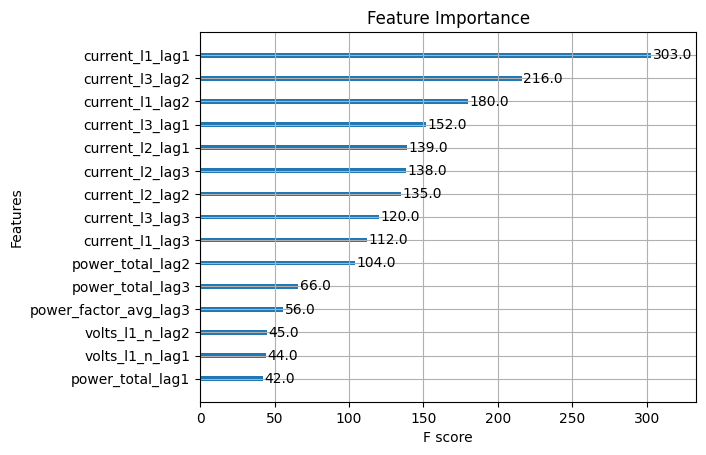

In [32]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15)
plt.title("Feature Importance")
plt.show()